<a href="https://colab.research.google.com/github/adnan-math/beam_fem_ml/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import dolfinx
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh" -O "/tmp/fenicsx-install.sh" && bash "/tmp/fenicsx-install.sh"
    import dolfinx

--2026-05-31 19:48:01--  https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4339 (4.2K) [application/x-sh]
Saving to: ‘/tmp/fenicsx-install.sh’

/tmp/fenicsx-instal 100%[===================>]   4.24K  --.-KB/s    in 0s      

2026-05-31 19:48:02 (33.8 MB/s) - ‘/tmp/fenicsx-install.sh’ saved [4339/4339]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICSX_INSTALLED=/usr/local/share/fem-on-colab/fenicsx.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenicsx.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/f823fc81/release

In [2]:
%cd /content
!rm -rf beam_fem_ml

!git clone https://github.com/adnan-math/beam_fem_ml.git
%cd beam_fem_ml

/content
Cloning into 'beam_fem_ml'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 13 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 174.16 KiB | 10.24 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/beam_fem_ml


In [3]:
!python data_generator.py

Running FEM for L = 0.50
[Mesh info] nx=25, ny=20, nz=20, total elements=10000
Running FEM for L = 0.55
[Mesh info] nx=27, ny=20, nz=20, total elements=10800
Running FEM for L = 0.60
[Mesh info] nx=30, ny=20, nz=20, total elements=12000
Running FEM for L = 0.65
[Mesh info] nx=32, ny=20, nz=20, total elements=12800
Running FEM for L = 0.70
[Mesh info] nx=35, ny=20, nz=20, total elements=14000
Running FEM for L = 0.75
[Mesh info] nx=37, ny=20, nz=20, total elements=14800
Running FEM for L = 0.80
[Mesh info] nx=40, ny=20, nz=20, total elements=16000
Running FEM for L = 0.85
[Mesh info] nx=42, ny=20, nz=20, total elements=16800
Running FEM for L = 0.90
[Mesh info] nx=45, ny=20, nz=20, total elements=18000
Running FEM for L = 0.95
[Mesh info] nx=47, ny=20, nz=20, total elements=18800
Running FEM for L = 1.00
[Mesh info] nx=50, ny=20, nz=20, total elements=20000
Running FEM for L = 1.05
[Mesh info] nx=52, ny=20, nz=20, total elements=20800
Running FEM for L = 1.10
[Mesh info] nx=55, ny=20, n

In [4]:
!python training.py

X shape: (2100, 2)
y shape: (2100,)
Train samples: 1300
Interpolation test samples: 1300
Extrapolation test samples: 800
Epoch 0 | Loss = 5.323496e-01
Epoch 100 | Loss = 1.542045e-04
Epoch 200 | Loss = 7.346495e-05
Epoch 300 | Loss = 3.387423e-04
Epoch 400 | Loss = 1.435717e-05
Epoch 500 | Loss = 4.771532e-06
Epoch 600 | Loss = 6.624322e-06
Epoch 700 | Loss = 1.163915e-05
Epoch 800 | Loss = 7.043914e-06
Epoch 900 | Loss = 4.903530e-06
Model saved: beam_mlp_model.pt


In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

# ============================================================
# LOAD DATA
# ============================================================

data = np.load("beam_fem_dataset.npz")
stats = np.load("norm_stats.npz")

X = data["X"]
y = data["y"]

X_mean, X_std = stats["X_mean"], stats["X_std"]
y_mean, y_std = stats["y_mean"], stats["y_std"]

# ============================================================
# LOAD MODEL
# ============================================================

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

model = MLP()
model.load_state_dict(torch.load("beam_mlp_model.pt"))
model.eval()

# ============================================================
# NORMALIZE INPUT
# ============================================================

Xn = (X - X_mean) / X_std

X_tensor = torch.tensor(Xn, dtype=torch.float32)

with torch.no_grad():
    pred_n = model(X_tensor).numpy().flatten()

pred = pred_n * y_std + y_mean

# ============================================================
# ERROR METRICS (INTERPOLATION / EXTRAPOLATION )
# ============================================================

L_values = np.unique(X[:, 0])

# MUST MATCH TRAINING SCRIPT
L_interp = np.array([0.8, 1.0, 1.2])

L_extrap = np.array([
    L for L in L_values
    if (L < 0.7) or (L > 1.3)
])

interp_mask = np.isin(X[:, 0], L_interp)
extrap_mask = np.isin(X[:, 0], L_extrap)

# ============================================================
# ERROR METRICS
# ============================================================

def compute_metrics(y_true, y_pred):

    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    rel_l2 = np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

    return mse, rmse, mae, rel_l2


mse_i, rmse_i, mae_i, rel_i = compute_metrics(y[interp_mask],pred[interp_mask])
print("\nINTERPOLATION")
print("MSE :", mse_i)
print("RMSE:", rmse_i)
print("MAE :", mae_i)
print("Rel L2:", rel_i)


mse_e, rmse_e, mae_e, rel_e = compute_metrics(y[extrap_mask],pred[extrap_mask])
print("\nEXTRAPOLATION")
print("MSE :", mse_e)
print("RMSE:", rmse_e)
print("MAE :", mae_e)
print("Rel L2:", rel_e)



# ============================================================
# ERROR CURVES PER LENGTH
# ============================================================

for L in L_values:
    mask = np.isclose(X[:, 0], L)

    err = np.mean(np.abs(y[mask] - pred[mask]))
    print(f"L = {L:.3f} | MAE = {err:.6e}")


INTERPOLATION
MSE : 1.5237727594329865e-19
RMSE: 3.9035532011655566e-10
MAE : 3.129094599021496e-10
Rel L2: 0.0008701706962646977

EXTRAPOLATION
MSE : 6.722812165215595e-15
RMSE: 8.199275678506971e-08
MAE : 5.216024965555296e-08
Rel L2: 0.07321774365295217
L = 0.500 | MAE = 2.037576e-08
L = 0.550 | MAE = 1.266935e-08
L = 0.600 | MAE = 8.237994e-09
L = 0.650 | MAE = 8.975891e-09
L = 0.700 | MAE = 1.810047e-10
L = 0.750 | MAE = 1.684367e-10
L = 0.800 | MAE = 2.404622e-10
L = 0.850 | MAE = 2.523240e-10
L = 0.900 | MAE = 3.729152e-10
L = 0.950 | MAE = 4.593997e-10
L = 1.000 | MAE = 3.853567e-10
L = 1.050 | MAE = 4.865758e-10
L = 1.100 | MAE = 4.229648e-10
L = 1.150 | MAE = 5.019315e-10
L = 1.200 | MAE = 4.339593e-10
L = 1.250 | MAE = 5.176697e-10
L = 1.300 | MAE = 3.721228e-10
L = 1.350 | MAE = 4.052363e-08
L = 1.400 | MAE = 6.574283e-08
L = 1.450 | MAE = 1.060781e-07
L = 1.500 | MAE = 1.546784e-07


[Mesh info] nx=39, ny=20, nz=20, total elements=15600


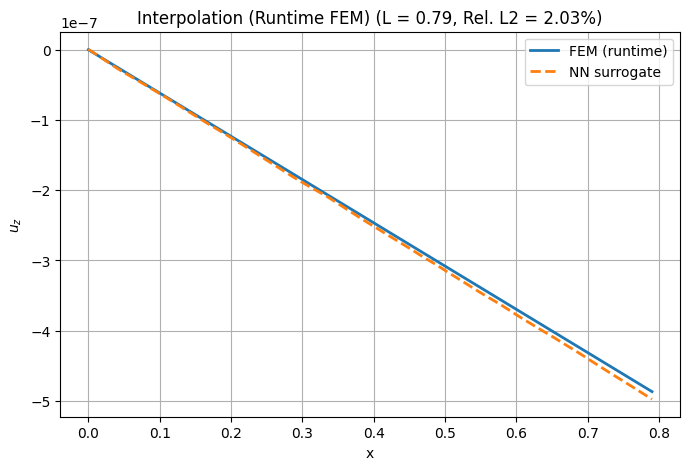

In [6]:
# ============================================================
# FEM vs NN (INTERPOLATION - RUNTIME FEM GENERATION)
# ============================================================

from fem_dataset import BeamDataset
import numpy as np
import matplotlib.pyplot as plt
import torch

# create FEM generator object
dataset = BeamDataset()

# choose unseen interpolation value
L_plot = 0.79

# ============================================================
# GENERATE FEM SOLUTION ON THE FLY
# ============================================================

data_L = dataset.generate(L_plot, n_points=100)

x = data_L[:, 1]
y_true = data_L[:, 2]

# ============================================================
# NN PREDICTION
# ============================================================

L_array = np.full_like(x, L_plot)

X_nn = np.stack([L_array, x], axis=1)

# normalize
X_nn = (X_nn - X_mean) / X_std

X_tensor = torch.tensor(X_nn, dtype=torch.float32)

with torch.no_grad():
    y_pred_n = model(X_tensor).numpy().flatten()

# denormalize
y_pred = y_pred_n * y_std + y_mean

# ============================================================
# SORT FOR PLOTTING
# ============================================================

idx = np.argsort(x)
x = x[idx]
y_true = y_true[idx]
y_pred = y_pred[idx]

# ============================================================
# ERROR
# ============================================================

rel_l2 = np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(8,5))
plt.plot(x, y_true, label="FEM (runtime)", linewidth=2)
plt.plot(x, y_pred, "--", label="NN surrogate", linewidth=2)

plt.xlabel("x")
plt.ylabel(r"$u_z$")
plt.title(
    f"Interpolation (Runtime FEM) "
    f"(L = {L_plot:.2f}, Rel. L2 = {100*rel_l2:.2f}%)"
)

plt.legend()
plt.grid()
plt.show()

[Mesh info] nx=25, ny=20, nz=20, total elements=10000
[Mesh info] nx=26, ny=20, nz=20, total elements=10400
[Mesh info] nx=27, ny=20, nz=20, total elements=10800
[Mesh info] nx=28, ny=20, nz=20, total elements=11200
[Mesh info] nx=29, ny=20, nz=20, total elements=11600
[Mesh info] nx=30, ny=20, nz=20, total elements=12000
[Mesh info] nx=31, ny=20, nz=20, total elements=12400
[Mesh info] nx=32, ny=20, nz=20, total elements=12800
[Mesh info] nx=33, ny=20, nz=20, total elements=13200
[Mesh info] nx=34, ny=20, nz=20, total elements=13600


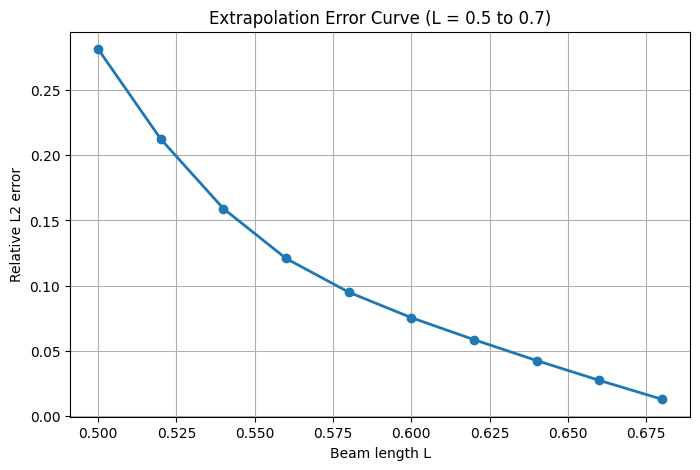

In [7]:
from fem_dataset import BeamDataset
import numpy as np
import matplotlib.pyplot as plt
import torch

dataset = BeamDataset()

# ============================================================
# EXTRAPOLATION RANGE
# ============================================================

L_extrap_curve = np.arange(0.5, 0.7, 0.02)

rel_l2_errors = []

# ============================================================
# LOOP OVER L VALUES
# ============================================================

for L_plot in L_extrap_curve:

    # -----------------------------
    # FEM solution (ground truth)
    # -----------------------------
    data_L = dataset.generate(L_plot, n_points=100)

    x = data_L[:, 1]
    y_true = data_L[:, 2]

    # -----------------------------
    # NN prediction
    # -----------------------------
    L_array = np.full_like(x, L_plot)

    X_nn = np.stack([L_array, x], axis=1)

    X_nn = (X_nn - X_mean) / X_std

    X_tensor = torch.tensor(X_nn, dtype=torch.float32)

    with torch.no_grad():
        y_pred_n = model(X_tensor).numpy().flatten()

    y_pred = y_pred_n * y_std + y_mean

    # -----------------------------
    # error
    # -----------------------------
    rel_l2 = np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

    rel_l2_errors.append(rel_l2)

# ============================================================
# PLOT ERROR CURVE
# ============================================================

plt.figure(figsize=(8,5))
plt.plot(L_extrap_curve, rel_l2_errors, marker='o', linewidth=2)

plt.xlabel("Beam length L")
plt.ylabel("Relative L2 error")
plt.title("Extrapolation Error Curve (L = 0.5 to 0.7)")
plt.grid()
plt.show()

[Mesh info] nx=25, ny=20, nz=20, total elements=10000
[Mesh info] nx=26, ny=20, nz=20, total elements=10400
[Mesh info] nx=27, ny=20, nz=20, total elements=10800
[Mesh info] nx=28, ny=20, nz=20, total elements=11200
[Mesh info] nx=29, ny=20, nz=20, total elements=11600
[Mesh info] nx=30, ny=20, nz=20, total elements=12000
[Mesh info] nx=31, ny=20, nz=20, total elements=12400
[Mesh info] nx=32, ny=20, nz=20, total elements=12800
[Mesh info] nx=33, ny=20, nz=20, total elements=13200
[Mesh info] nx=34, ny=20, nz=20, total elements=13600
[Mesh info] nx=35, ny=20, nz=20, total elements=14000
[Mesh info] nx=37, ny=20, nz=20, total elements=14800
[Mesh info] nx=39, ny=20, nz=20, total elements=15600
[Mesh info] nx=41, ny=20, nz=20, total elements=16400
[Mesh info] nx=43, ny=20, nz=20, total elements=17200
[Mesh info] nx=45, ny=20, nz=20, total elements=18000
[Mesh info] nx=47, ny=20, nz=20, total elements=18800
[Mesh info] nx=49, ny=20, nz=20, total elements=19600
[Mesh info] nx=51, ny=20, nz

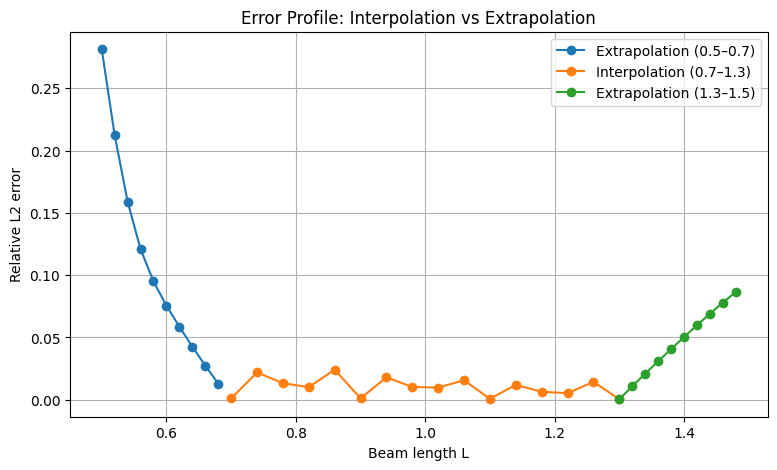

In [8]:
from fem_dataset import BeamDataset
import numpy as np
import matplotlib.pyplot as plt
import torch

dataset = BeamDataset()

# ============================================================
# L RANGES
# ============================================================

L_extrap_left  = np.arange(0.5, 0.7, 0.02)
L_interp       = np.arange(0.7, 1.3, 0.04)
L_extrap_right = np.arange(1.3, 1.5, 0.02)

# ============================================================
# STORAGE
# ============================================================

err_left = []
err_interp = []
err_right = []

# ============================================================
# ERROR FUNCTION
# ============================================================

def compute_rel_l2(L_plot):

    data_L = dataset.generate(L_plot, n_points=100)

    x = data_L[:, 1]
    y_true = data_L[:, 2]

    L_array = np.full_like(x, L_plot)
    X_nn = np.stack([L_array, x], axis=1)

    X_nn = (X_nn - X_mean) / X_std

    X_tensor = torch.tensor(X_nn, dtype=torch.float32)

    with torch.no_grad():
        y_pred_n = model(X_tensor).numpy().flatten()

    y_pred = y_pred_n * y_std + y_mean

    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

# ============================================================
# LEFT EXTRAPOLATION
# ============================================================

for L in L_extrap_left:
    err_left.append(compute_rel_l2(L))

# ============================================================
# INTERPOLATION
# ============================================================

for L in L_interp:
    err_interp.append(compute_rel_l2(L))

# ============================================================
# RIGHT EXTRAPOLATION
# ============================================================

for L in L_extrap_right:
    err_right.append(compute_rel_l2(L))

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9,5))

plt.plot(L_extrap_left, err_left, marker='o', label="Extrapolation (0.5–0.7)")
plt.plot(L_interp, err_interp, marker='o', label="Interpolation (0.7–1.3)")
plt.plot(L_extrap_right, err_right, marker='o', label="Extrapolation (1.3–1.5)")

plt.xlabel("Beam length L")
plt.ylabel("Relative L2 error")
plt.title("Error Profile: Interpolation vs Extrapolation")
plt.legend()
plt.grid()
plt.show()

In [10]:
import numpy as np
import pyvista as pv
import imageio
from dolfinx import fem, plot
from fem_dataset import BeamDataset

# ============================================================
# DATASET
# ============================================================

dataset = BeamDataset()

# ============================================================
# PARAMETER SWEEP
# ============================================================

L_values = np.linspace(0.5, 1.5, 5)

warp_factor = 3000  # adjust for visibility

frames = []

# ============================================================
# INITIAL SOLVE (for camera + mesh reference)
# ============================================================

L0 = L_values[0]
domain, V, uh = dataset.solve(L0, dataset.traction)

topology, cell_types, geom = plot.vtk_mesh(V)

# ============================================================
# PYVISTA SETUP
# ============================================================

p = pv.Plotter(off_screen=True, window_size=(1200, 800))

grid_ref = pv.UnstructuredGrid(topology, cell_types, geom.copy())
grid_fem = pv.UnstructuredGrid(topology, cell_types, geom.copy())

# reference mesh
p.add_mesh(
    grid_ref,
    style="wireframe",
    color="black",
    opacity=0.25
)

# dynamic mesh actor (created once)
fem_actor = p.add_mesh(
    grid_fem,
    cmap="viridis",
    show_scalar_bar=True
)

# ============================================================
# CAMERA SETUP
# ============================================================

bounds = grid_ref.bounds
xmin, xmax, ymin, ymax, zmin, zmax = bounds

xc = 0.5 * (xmin + xmax)
yc = 0.5 * (ymin + ymax)
zc = 0.5 * (zmin + zmax)

dx = xmax - xmin
dy = ymax - ymin
dz = zmax - zmin

# IMPORTANT: enlarge view so deformation never exits frame
margin = 2.0

camera_pos = (
    xc + 0.4 * dx * margin,
    yc + 3.5 * dy * margin,
    zc + 0.8 * dz * margin,
)

p.camera_position = [
    camera_pos,
    (xc, yc, zc),
    (0, 0, 1),
]

# CRITICAL FIX: prevents perspective zoom distortion
p.enable_parallel_projection()

# lock camera scaling/clipping
p.reset_camera_clipping_range()

# slight zoom out for safety
p.camera.zoom(0.9)

# background (keep clean)
for r in p.renderers:
    r.SetBackground(1, 1, 1)

# ============================================================
# TEXT LABEL (L + SCALE)
# ============================================================

info_text = p.add_text("", font_size=14, color="black")

# ============================================================
# GLOBAL COLOR RANGE (optional stability)
# ============================================================

all_uz = []

solutions = []

# ============================================================
# STEP 1: PRECOMPUTE SOLUTIONS (SAFE + STABLE)
# ============================================================

for L in L_values:

    domain, V, uh = dataset.solve(L, dataset.traction)

    u_interp = fem.Function(V)
    u_interp.interpolate(uh)

    u = u_interp.x.array.reshape(-1, 3)

    # IMPORTANT: negative deflection convention
    uz = -u[:, 2]

    solutions.append((V, u, uz))
    all_uz.append(uz)

all_uz = np.concatenate(all_uz)
vmin, vmax = all_uz.min(), all_uz.max()

# ============================================================
# STEP 2: ANIMATION LOOP
# ============================================================

for i, (V, u, uz) in enumerate(solutions):

    coords = V.mesh.geometry.x

    # --------------------------------------------------------
    # REBUILD MESH (SAFE FOR VARIABLE MESH SIZE)
    # --------------------------------------------------------

    topology, cell_types, geom = plot.vtk_mesh(V)

    grid_ref = pv.UnstructuredGrid(topology, cell_types, geom.copy())
    grid_fem = pv.UnstructuredGrid(topology, cell_types, geom.copy())

    grid_fem.point_data["u"] = uz

    # --------------------------------------------------------
    # WARP
    # --------------------------------------------------------

    warped = grid_fem.warp_by_scalar("u", factor=warp_factor)

    # --------------------------------------------------------
    # UPDATE ACTOR (SAFE)
    # --------------------------------------------------------

    fem_actor.mapper.dataset = warped
    fem_actor.mapper.scalar_range = (vmin, vmax)

    # --------------------------------------------------------
    # UPDATE TEXT (L + SCALE)
    # --------------------------------------------------------

    L = L_values[i]

    info_text.SetText(
        0,
        rf"$L = {L:.3f}$   |   scale = {warp_factor}"
    )

    # --------------------------------------------------------
    # RENDER FRAME
    # --------------------------------------------------------

    p.render()

    img = p.screenshot(None, return_img=True)
    frames.append(img)

# ============================================================
# EXPORT
# ============================================================

imageio.mimsave("beam_L_animation.gif", frames, fps=3)
imageio.mimsave("beam_L_animation.mp4", frames, fps=3)

print("Saved: beam_L_animation.gif + beam_L_animation.mp4")

[Mesh info] nx=25, ny=20, nz=20, total elements=10000
[Mesh info] nx=25, ny=20, nz=20, total elements=10000
[Mesh info] nx=37, ny=20, nz=20, total elements=14800
[Mesh info] nx=50, ny=20, nz=20, total elements=20000
[Mesh info] nx=62, ny=20, nz=20, total elements=24800
[Mesh info] nx=75, ny=20, nz=20, total elements=30000
Saved: beam_L_animation.gif + beam_L_animation.mp4
